# Treatment Patterns with OMOPy

This notebook demonstrates `omopy.treatment` for treatment pathway computation, summarisation, and visualisation on OMOP CDM data.

**Covered:**
- Computing treatment pathways from cohort tables
- Examining the PathwayResult object
- Summarising pathway frequencies and event durations
- Pathway tables (frequency and duration)
- Sankey diagrams, sunburst charts, and duration plots
- Mock data for richer demonstrations
- Advanced options: combination_window, era_collapse_size, min_era_duration

**Database:** Synthea DuckDB with 27 persons, 663 drug_exposure records, 32 unique drug concepts.
Mock data is used for larger-sample demonstrations.

## 1. Configuration

In [1]:
DB_PATH = "../data/synthea.duckdb"
CDM_SCHEMA = "base"
WRITE_SCHEMA = "main"

## 2. Setup

Connect to the CDM and generate a single cohort table containing both target and event cohorts.
`CohortSpec` objects tell `compute_pathways` which cohort IDs are targets and which are events.

In [2]:
from omopy.connector import cdm_from_con, generate_concept_cohort_set
from omopy.generics import Codelist
from omopy.treatment import (
    CohortSpec,
    compute_pathways,
    summarise_treatment_pathways,
    summarise_event_duration,
    table_treatment_pathways,
    table_event_duration,
    plot_sankey,
    plot_sunburst,
    plot_event_duration,
    mock_treatment_pathways,
)

print("Imports OK")

Imports OK


In [3]:
cdm = cdm_from_con(DB_PATH, cdm_schema=CDM_SCHEMA, write_schema=WRITE_SCHEMA)
print(cdm)
print(f"Persons: {cdm['person'].count()}")

CdmReference(name='dbt-synthea', version=5.4, source=duckdb, tables=36)
Persons: 27


In [4]:
# Create a single cohort table with target + event concepts
concept_set = Codelist({
    "hypertension": [320128],
    "sinusitis": [40481087],
    "hypertension_drug": [320128],
})
cdm = generate_concept_cohort_set(cdm, concept_set, name="study")
cohort = cdm["study"]
print("Study cohort (target + events):")
print(cohort)

Study cohort (target + events):
CohortTable('study', source='duckdb', cohorts=3)


In [5]:
# Define which cohort IDs are targets and which are events
cohort_specs = [
    CohortSpec(cohort_id=1, cohort_name="hypertension", type="target"),
    CohortSpec(cohort_id=2, cohort_name="sinusitis", type="event"),
    CohortSpec(cohort_id=3, cohort_name="hypertension_drug", type="event"),
]
print("Cohort specs:")
for spec in cohort_specs:
    print(f"  id={spec.cohort_id}, name={spec.cohort_name}, type={spec.type}")

Cohort specs:
  id=1, name=hypertension, type=target
  id=2, name=sinusitis, type=event
  id=3, name=hypertension_drug, type=event


## 3. Computing Pathways

`compute_pathways` traces treatment sequences for each person in the target cohort,
using the event cohorts as the set of possible treatment elements.

It takes a single `cohort` (CohortTable) and a list of `CohortSpec` objects that
specify which cohort IDs are targets vs events.

Key parameters:
- `combination_window`: days within which overlapping events are treated as a combination therapy
- `min_era_duration`: minimum days an event must last to be included
- `max_path_length`: maximum number of treatment lines to track
- `era_collapse_size`: gap (days) within which consecutive same-event eras are merged

In [6]:
# Basic pathway computation with default settings
pw = compute_pathways(
    cohort,
    cdm,
    cohort_specs,
)
print(pw)

treatment_history=shape: (8, 12)
┌───────────┬────────────┬─────────────┬─────────────┬───┬─────┬────────┬─────────────┬────────────┐
│ person_id ┆ index_year ┆ event_cohor ┆ event_cohor ┆ … ┆ age ┆ sex    ┆ target_coho ┆ target_coh │
│ ---       ┆ ---        ┆ t_id        ┆ t_name      ┆   ┆ --- ┆ ---    ┆ rt_id       ┆ ort_name   │
│ i64       ┆ i64        ┆ ---         ┆ ---         ┆   ┆ i64 ┆ str    ┆ ---         ┆ ---        │
│           ┆            ┆ str         ┆ str         ┆   ┆     ┆        ┆ i64         ┆ str        │
╞═══════════╪════════════╪═════════════╪═════════════╪═══╪═════╪════════╪═════════════╪════════════╡
│ 5         ┆ 1991       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Male   ┆ 1           ┆ hypertensi │
│           ┆            ┆             ┆ n_drug      ┆   ┆     ┆        ┆             ┆ on         │
│ 15        ┆ 2005       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Female ┆ 1           ┆ hypertensi │
│           ┆            ┆             ┆ n_drug      ┆   ┆

In [7]:
# With a combination window: events starting within 30 days are combined
pw_combo = compute_pathways(
    cohort,
    cdm,
    cohort_specs,
    combination_window=30,
)
print("With combination_window=30:")
print(pw_combo)

With combination_window=30:
treatment_history=shape: (8, 12)
┌───────────┬────────────┬─────────────┬─────────────┬───┬─────┬────────┬─────────────┬────────────┐
│ person_id ┆ index_year ┆ event_cohor ┆ event_cohor ┆ … ┆ age ┆ sex    ┆ target_coho ┆ target_coh │
│ ---       ┆ ---        ┆ t_id        ┆ t_name      ┆   ┆ --- ┆ ---    ┆ rt_id       ┆ ort_name   │
│ i64       ┆ i64        ┆ ---         ┆ ---         ┆   ┆ i64 ┆ str    ┆ ---         ┆ ---        │
│           ┆            ┆ str         ┆ str         ┆   ┆     ┆        ┆ i64         ┆ str        │
╞═══════════╪════════════╪═════════════╪═════════════╪═══╪═════╪════════╪═════════════╪════════════╡
│ 5         ┆ 1991       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Male   ┆ 1           ┆ hypertensi │
│           ┆            ┆             ┆ n_drug      ┆   ┆     ┆        ┆             ┆ on         │
│ 15        ┆ 2005       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Female ┆ 1           ┆ hypertensi │
│           ┆            ┆    

In [8]:
# Restrict to shorter path lengths
pw_short = compute_pathways(
    cohort,
    cdm,
    cohort_specs,
    max_path_length=3,
)
print("With max_path_length=3:")
print(pw_short)

With max_path_length=3:
treatment_history=shape: (8, 12)
┌───────────┬────────────┬─────────────┬─────────────┬───┬─────┬────────┬─────────────┬────────────┐
│ person_id ┆ index_year ┆ event_cohor ┆ event_cohor ┆ … ┆ age ┆ sex    ┆ target_coho ┆ target_coh │
│ ---       ┆ ---        ┆ t_id        ┆ t_name      ┆   ┆ --- ┆ ---    ┆ rt_id       ┆ ort_name   │
│ i64       ┆ i64        ┆ ---         ┆ ---         ┆   ┆ i64 ┆ str    ┆ ---         ┆ ---        │
│           ┆            ┆ str         ┆ str         ┆   ┆     ┆        ┆ i64         ┆ str        │
╞═══════════╪════════════╪═════════════╪═════════════╪═══╪═════╪════════╪═════════════╪════════════╡
│ 5         ┆ 1991       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Male   ┆ 1           ┆ hypertensi │
│           ┆            ┆             ┆ n_drug      ┆   ┆     ┆        ┆             ┆ on         │
│ 15        ┆ 2005       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Female ┆ 1           ┆ hypertensi │
│           ┆            ┆        

In [9]:
# Require minimum era duration of 7 days
pw_min_era = compute_pathways(
    cohort,
    cdm,
    cohort_specs,
    min_era_duration=7,
)
print("With min_era_duration=7:")
print(pw_min_era)

With min_era_duration=7:
treatment_history=shape: (8, 12)
┌───────────┬────────────┬─────────────┬─────────────┬───┬─────┬────────┬─────────────┬────────────┐
│ person_id ┆ index_year ┆ event_cohor ┆ event_cohor ┆ … ┆ age ┆ sex    ┆ target_coho ┆ target_coh │
│ ---       ┆ ---        ┆ t_id        ┆ t_name      ┆   ┆ --- ┆ ---    ┆ rt_id       ┆ ort_name   │
│ i64       ┆ i64        ┆ ---         ┆ ---         ┆   ┆ i64 ┆ str    ┆ ---         ┆ ---        │
│           ┆            ┆ str         ┆ str         ┆   ┆     ┆        ┆ i64         ┆ str        │
╞═══════════╪════════════╪═════════════╪═════════════╪═══╪═════╪════════╪═════════════╪════════════╡
│ 5         ┆ 1991       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Male   ┆ 1           ┆ hypertensi │
│           ┆            ┆             ┆ n_drug      ┆   ┆     ┆        ┆             ┆ on         │
│ 15        ┆ 2005       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Female ┆ 1           ┆ hypertensi │
│           ┆            ┆       

## 4. Examining PathwayResult

The `PathwayResult` object holds the computed pathway data and the settings used.

Key attributes:
- `treatment_history`: DataFrame of per-person treatment sequences
- `attrition`: DataFrame tracking cohort attrition
- `cohorts`: tuple of CohortSpec objects used
- `cdm_name`: name of the CDM source
- `arguments`: dict of parameters used in the computation

In [10]:
# The .treatment_history attribute contains the per-person pathway sequences
print("PathwayResult.treatment_history:")
print(pw.treatment_history)

PathwayResult.treatment_history:
shape: (8, 12)
┌───────────┬────────────┬─────────────┬─────────────┬───┬─────┬────────┬─────────────┬────────────┐
│ person_id ┆ index_year ┆ event_cohor ┆ event_cohor ┆ … ┆ age ┆ sex    ┆ target_coho ┆ target_coh │
│ ---       ┆ ---        ┆ t_id        ┆ t_name      ┆   ┆ --- ┆ ---    ┆ rt_id       ┆ ort_name   │
│ i64       ┆ i64        ┆ ---         ┆ ---         ┆   ┆ i64 ┆ str    ┆ ---         ┆ ---        │
│           ┆            ┆ str         ┆ str         ┆   ┆     ┆        ┆ i64         ┆ str        │
╞═══════════╪════════════╪═════════════╪═════════════╪═══╪═════╪════════╪═════════════╪════════════╡
│ 5         ┆ 1991       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Male   ┆ 1           ┆ hypertensi │
│           ┆            ┆             ┆ n_drug      ┆   ┆     ┆        ┆             ┆ on         │
│ 15        ┆ 2005       ┆ 3           ┆ hypertensio ┆ … ┆ 18  ┆ Female ┆ 1           ┆ hypertensi │
│           ┆            ┆             ┆ n_

In [11]:
# The .arguments attribute records the parameters used
print("PathwayResult.arguments:")
print(pw.arguments)

print("\nPathwayResult.cohorts:")
print(pw.cohorts)

print("\nPathwayResult.cdm_name:")
print(pw.cdm_name)

print("\nPathwayResult.attrition:")
print(pw.attrition)

PathwayResult.arguments:
{'start_anchor': 'start_date', 'window_start': 0, 'end_anchor': 'end_date', 'window_end': 0, 'min_era_duration': 0, 'split_event_cohorts': None, 'split_time': None, 'era_collapse_size': 30, 'combination_window': 30, 'min_post_combination_duration': 30, 'filter_treatments': 'first', 'max_path_length': 5, 'overlap_method': 'truncate', 'concat_targets': True}

PathwayResult.cohorts:
(CohortSpec(cohort_id=1, cohort_name='hypertension', type='target'), CohortSpec(cohort_id=2, cohort_name='sinusitis', type='event'), CohortSpec(cohort_id=3, cohort_name='hypertension_drug', type='event'))

PathwayResult.cdm_name:
dbt-synthea

PathwayResult.attrition:
shape: (7, 6)
┌────────────────┬─────────────────┬───────────┬─────────────────┬────────────────┬────────────────┐
│ number_records ┆ number_subjects ┆ reason_id ┆ reason          ┆ target_cohort_ ┆ target_cohort_ │
│ ---            ┆ ---             ┆ ---       ┆ ---             ┆ id             ┆ name           │
│ i64  

## 5. Summarise Treatment Pathways

`summarise_treatment_pathways` aggregates pathway sequences into frequency counts.
Takes a `PathwayResult` and returns a `SummarisedResult`.

We use `min_cell_count=0` because Synthea only has 27 persons.

In [12]:
summary = summarise_treatment_pathways(pw, min_cell_count=0)
print(summary)

SummarisedResult(6 rows, 1 result_id(s))


In [13]:
# Summary from the combination-window result
summary_combo = summarise_treatment_pathways(pw_combo, min_cell_count=0)
print("Pathway summary with combination_window=30:")
print(summary_combo)

Pathway summary with combination_window=30:
SummarisedResult(6 rows, 1 result_id(s))


## 6. Pathway Tables

`table_treatment_pathways` renders a formatted table of pathway frequencies.

In [14]:
table_treatment_pathways(summary)

GT(_tbl_data=       variable_name                                 variable_level  \
0  treatment_pathway                              hypertension_drug   
1  treatment_pathway  hypertension_drug-hypertension_drug+sinusitis   
2     Number records                                                  
3    Number subjects                                                  
4  treatment_pathway                              hypertension_drug   
5  treatment_pathway  hypertension_drug-hypertension_drug+sinusitis   

  estimate_name [header_name]cdm_name\n[header_level]dbt-synthea  \
0             N                                                4   
1             N                                                2   
2             N                                                6   
3             N                                                6   
4             %                                            66.7%   
5             %                                            33.3%   

  target_cohort_name  
0       hypertension  
1       hypertension  
2       hypertension  
3       hypertension  
4       hypertension  
5       hypertension  , _body=<great_tables._gt_data.Body object at 0x727d2b7c12b0>, _boxhead=Boxhead([ColInfo(var='variable_name', type=<ColInfoTypeEnum.default: 1>, column_label='variable_name', column_align='left', column_width=None), ColInfo(var='variable_level', type=<ColInfoTypeEnum.default: 1>, column_label='variable_level', column_align='left', column_width=None), ColInfo(var='estimate_name', type=<ColInfoTypeEnum.default: 1>, column_label='estimate_name', column_align='left', column_width=None), ColInfo(var='[header_name]cdm_name\n[header_level]dbt-synthea', type=<ColInfoTypeEnum.default: 1>, column_label='dbt-synthea', column_align='right', column_width=None), ColInfo(var='target_cohort_name', type=<ColInfoTypeEnum.default: 1>, column_label='target_cohort_name', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x727d2b7c0c20>, _spanners=Spanners([SpannerInfo(spanner_id='cdm_name', spanner_level=0, spanner_label='cdm_name', spanner_units=None, spanner_pattern=None, vars=['[header_name]cdm_name\n[header_level]dbt-synthea'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x727d2b7c16a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x727d88033890>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_level', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='estimate_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='[header_name]cdm_name\n[header_level]dbt-synthea', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='target_cohort_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_name', rownum=None, colnum=None, styles=[CellStyleText(color='#ffffff', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_level', rownum=None, colnum=None, styles=[CellStyleText(color='#ffffff', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='estimate_name', 

In [15]:
# Specify output type
table_treatment_pathways(summary, type="gt")

GT(_tbl_data=       variable_name                                 variable_level  \
0  treatment_pathway                              hypertension_drug   
1  treatment_pathway  hypertension_drug-hypertension_drug+sinusitis   
2     Number records                                                  
3    Number subjects                                                  
4  treatment_pathway                              hypertension_drug   
5  treatment_pathway  hypertension_drug-hypertension_drug+sinusitis   

  estimate_name [header_name]cdm_name\n[header_level]dbt-synthea  \
0             N                                                4   
1             N                                                2   
2             N                                                6   
3             N                                                6   
4             %                                            66.7%   
5             %                                            33.3%   

  target_cohort_name  
0       hypertension  
1       hypertension  
2       hypertension  
3       hypertension  
4       hypertension  
5       hypertension  , _body=<great_tables._gt_data.Body object at 0x727d2b7a5a70>, _boxhead=Boxhead([ColInfo(var='variable_name', type=<ColInfoTypeEnum.default: 1>, column_label='variable_name', column_align='left', column_width=None), ColInfo(var='variable_level', type=<ColInfoTypeEnum.default: 1>, column_label='variable_level', column_align='left', column_width=None), ColInfo(var='estimate_name', type=<ColInfoTypeEnum.default: 1>, column_label='estimate_name', column_align='left', column_width=None), ColInfo(var='[header_name]cdm_name\n[header_level]dbt-synthea', type=<ColInfoTypeEnum.default: 1>, column_label='dbt-synthea', column_align='right', column_width=None), ColInfo(var='target_cohort_name', type=<ColInfoTypeEnum.default: 1>, column_label='target_cohort_name', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x727d2b7dc690>, _spanners=Spanners([SpannerInfo(spanner_id='cdm_name', spanner_level=0, spanner_label='cdm_name', spanner_units=None, spanner_pattern=None, vars=['[header_name]cdm_name\n[header_level]dbt-synthea'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x727d2b7dc050>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x727d2b7a5cd0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_level', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='estimate_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='[header_name]cdm_name\n[header_level]dbt-synthea', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='target_cohort_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_name', rownum=None, colnum=None, styles=[CellStyleText(color='#ffffff', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_level', rownum=None, colnum=None, styles=[CellStyleText(color='#ffffff', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='estimate_name', 

## 7. Sankey Diagram

`plot_sankey` visualises treatment flows from one line to the next.

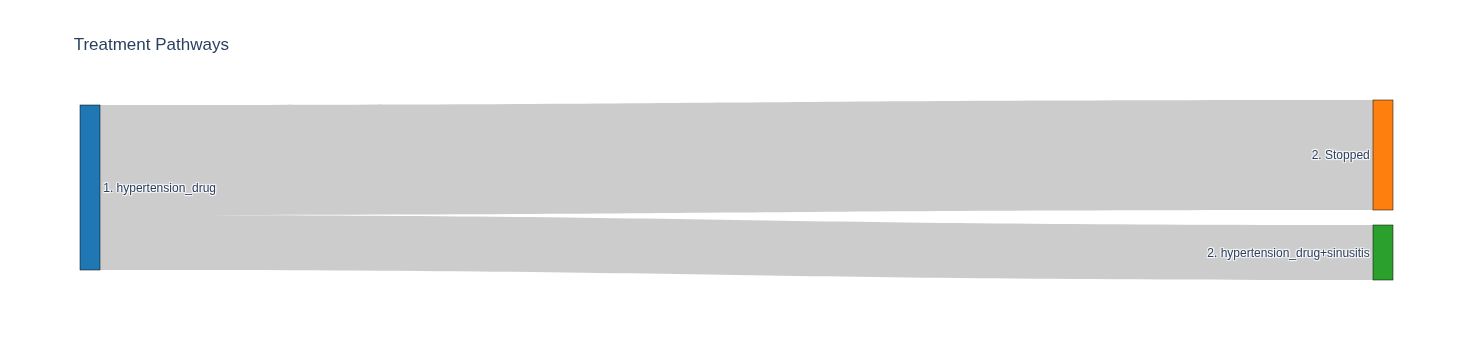

In [16]:
plot_sankey(summary)

## 8. Sunburst Chart

`plot_sunburst` shows pathway hierarchy as concentric rings — inner ring is first-line therapy, outer rings are subsequent lines.

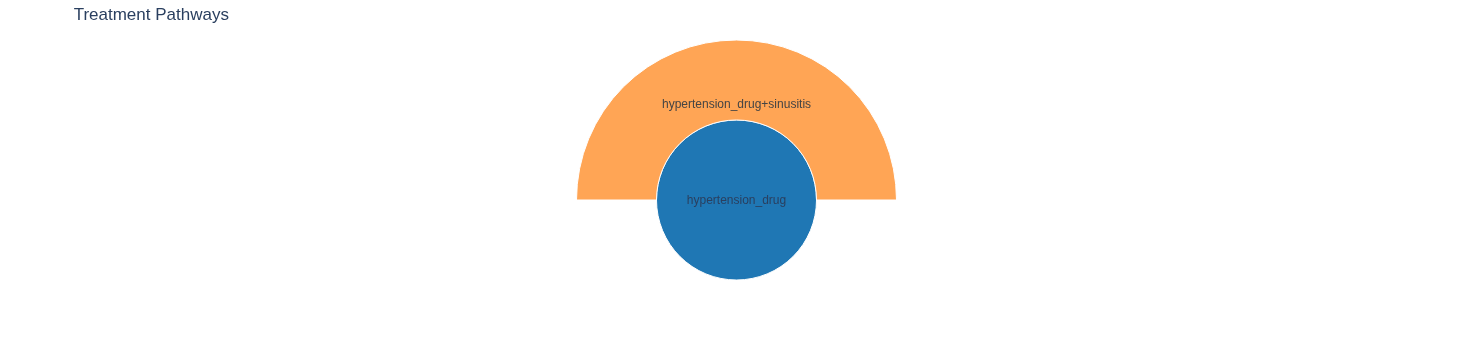

In [17]:
plot_sunburst(summary)

## 9. Event Duration

`summarise_event_duration` computes duration statistics per treatment event.
`table_event_duration` and `plot_event_duration` display the results.

In [18]:
dur_summary = summarise_event_duration(pw, min_cell_count=0)
print(dur_summary)

SummarisedResult(64 rows, 1 result_id(s))


In [19]:
table_event_duration(dur_summary)

GT(_tbl_data=                  variable_name variable_level       estimate_name  \
0                    mono-event                                  N   
1             combination-event                                  N   
2             hypertension_drug                                  N   
3   hypertension_drug+sinusitis                                  N   
4                    mono-event                                  N   
5             hypertension_drug                                  N   
6             combination-event                                  N   
7   hypertension_drug+sinusitis                                  N   
8                    mono-event                          Mean (SD)   
9             combination-event                          Mean (SD)   
10            hypertension_drug                          Mean (SD)   
11  hypertension_drug+sinusitis                          Mean (SD)   
12                   mono-event                          Mean (SD)   
13            hypertension_drug                          Mean (SD)   
14            combination-event                          Mean (SD)   
15  hypertension_drug+sinusitis                          Mean (SD)   
16                   mono-event                 Median [Q25 - Q75]   
17            combination-event                 Median [Q25 - Q75]   
18            hypertension_drug                 Median [Q25 - Q75]   
19  hypertension_drug+sinusitis                 Median [Q25 - Q75]   
20                   mono-event                 Median [Q25 - Q75]   
21            hypertension_drug                 Median [Q25 - Q75]   
22            combination-event                 Median [Q25 - Q75]   
23  hypertension_drug+sinusitis                 Median [Q25 - Q75]   
24                   mono-event                              Range   
25            combination-event                              Range   
26            hypertension_drug                              Range   
27  hypertension_drug+sinusitis                              Range   
28                   mono-event                              Range   
29            hypertension_drug                              Range   
30            combination-event                              Range   
31  hypertension_drug+sinusitis                              Range   

   [header_name]cdm_name\n[header_level]dbt-synthea target_cohort_name  \
0                                                 6       hypertension   
1                                                 2       hypertension   
2                                                 6       hypertension   
3                                                 2       hypertension   
4                                                 6       hypertension   
5                                                 6       hypertension   
6                                                 2       hypertension   
7                                                 2       hypertension   
8                              10,802.17 (4,257.08)       hypertension   
9                                   175.50 (130.81)       hypertension   
10                             10,802.17 (4,257.08)       hypertension   
11                                  175.50 (130.81)       hypertension   
12                             10,802.17 (4,257.08)       hypertension   
13                             10,802.17 (4,257.08)       hypertension   
14                                  175.50 (130.81)       hypertension   
15                                  175.50 (130.81)       hypertension   
16                 10,042.00 [7,420.00 - 12,346.00]       hypertension   
17                          175.00 [83.00 - 268.00]       hypertension   
18                 10,042.00 [7,420.00 - 12,346.00]       hypertension   
19                          175.00 [83.00 - 268.00]       hypertension   
20                 10,042.00 [7,420.00 - 12,346.00]       hypertension   
21                 10,042.00 [7,420.00 - 12,346.

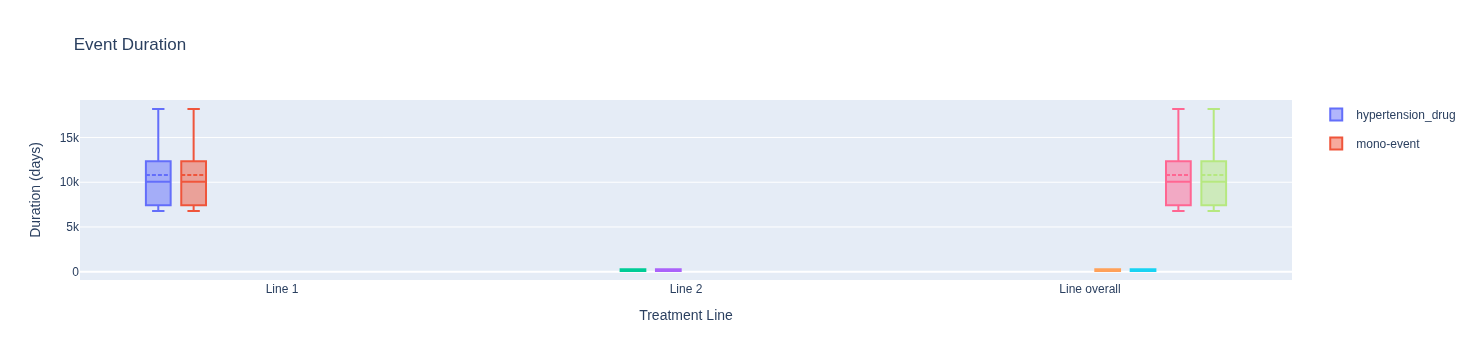

In [20]:
plot_event_duration(dur_summary)

## 10. Using Mock Data

With only 27 persons in Synthea, pathway analyses are sparse.
`mock_treatment_pathways` generates a synthetic `SummarisedResult` with richer patterns.
Since mock returns a `SummarisedResult` directly, table and plot functions work on it without summarisation.

In [21]:
# Basic mock pathway data (returns SummarisedResult directly)
mock_pw = mock_treatment_pathways(seed=42)
print(mock_pw)

SummarisedResult(220 rows, 2 result_id(s))


In [22]:
# Pathway frequency table from mock data
table_treatment_pathways(mock_pw)

GT(_tbl_data=        variable_name                                     variable_level  \
0   treatment_pathway                                          Metformin   
1   treatment_pathway                                            Aspirin   
2   treatment_pathway                       Aspirin+Atorvastatin-Aspirin   
3   treatment_pathway                            Atorvastatin-Lisinopril   
4   treatment_pathway         Lisinopril+Metformin-Lisinopril-Lisinopril   
5   treatment_pathway                                         Lisinopril   
6   treatment_pathway                       Aspirin-Aspirin-Atorvastatin   
7   treatment_pathway                                 Aspirin-Lisinopril   
8   treatment_pathway  Aspirin-Atorvastatin-Lisinopril-Lisinopril-Lis...   
9   treatment_pathway                        Aspirin-Metformin-Metformin   
10  treatment_pathway                                    Aspirin-Aspirin   
11  treatment_pathway                    Aspirin-Lisinopril-Atorvastatin   
12  treatment_pathway                                       Atorvastatin   
13     Number records                                                      
14    Number subjects                                                      
15  treatment_pathway                                          Metformin   
16  treatment_pathway                                            Aspirin   
17  treatment_pathway                       Aspirin+Atorvastatin-Aspirin   
18  treatment_pathway                            Atorvastatin-Lisinopril   
19  treatment_pathway         Lisinopril+Metformin-Lisinopril-Lisinopril   
20  treatment_pathway                                         Lisinopril   
21  treatment_pathway                       Aspirin-Aspirin-Atorvastatin   
22  treatment_pathway                                 Aspirin-Lisinopril   
23  treatment_pathway  Aspirin-Atorvastatin-Lisinopril-Lisinopril-Lis...   
24  treatment_pathway                        Aspirin-Metformin-Metformin   
25  treatment_pathway                                    Aspirin-Aspirin   
26  treatment_pathway                    Aspirin-Lisinopril-Atorvastatin   
27  treatment_pathway                                       Atorvastatin   

   estimate_name [header_name]cdm_name\n[header_level]mock_cdm  \
0              N                                           122   
1              N                                           103   
2              N                                           203   
3              N                                           111   
4              N                                           102   
5              N                                            48   
6              N                                            45   
7              N                                            25   
8              N                                            37   
9              N                                             8   
10             N                                            12   
11             N                                            12   
12             N                                            26   
13             N                                           882   
14             N                                           854   
15             %                                         14.3%   
16             %                                         12.1%   
17             %                                         23.8%   
18             %                                         13.0%   
19             %                                         11.9%   
20             %                                          5.6%   
21             %                                          5.3%   
22             %                                          2.9%   
23             %                                          4.3%   
24             %                                          0.9%   
25             %                                          1.4%   


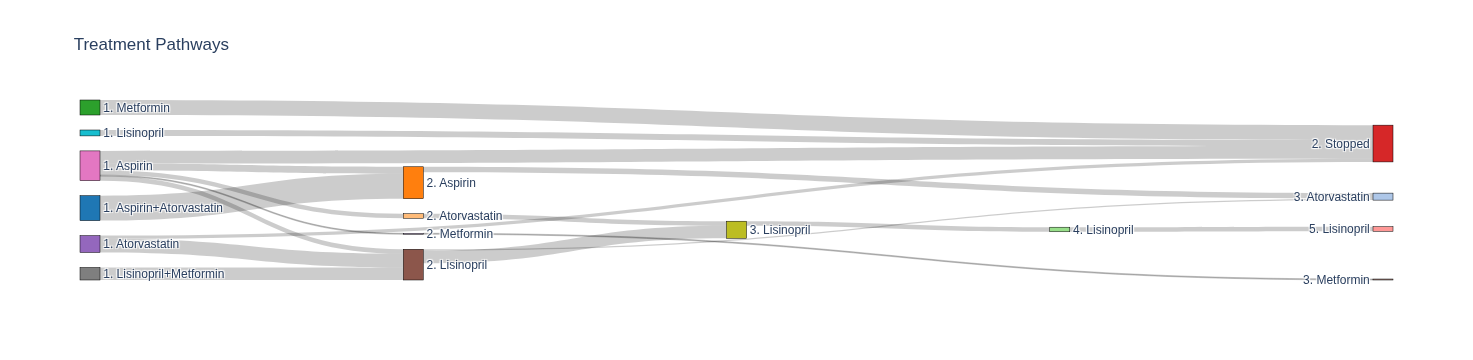

In [23]:
# Sankey diagram from mock data
plot_sankey(mock_pw)

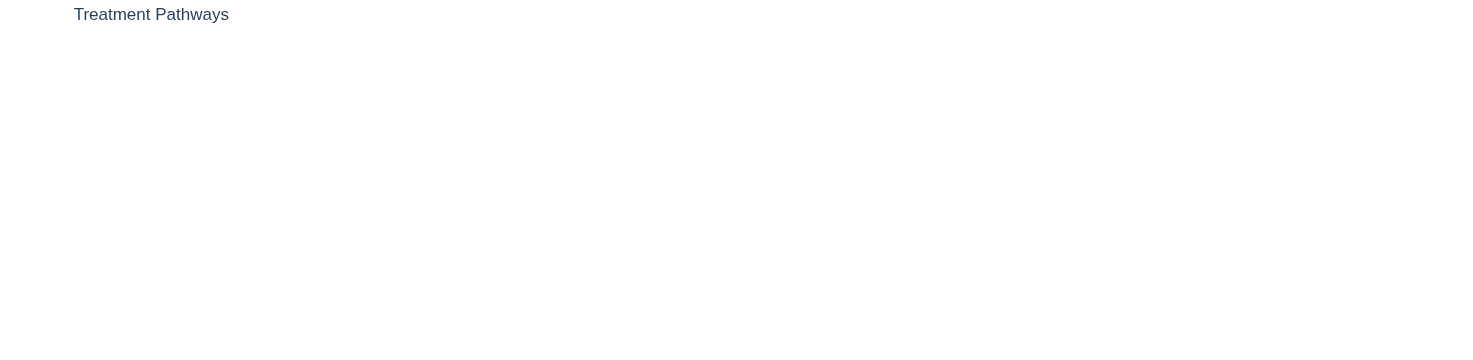

In [24]:
# Sunburst chart from mock data
plot_sunburst(mock_pw)

In [25]:
# Mock with duration information
mock_dur = mock_treatment_pathways(seed=99, include_duration=True)
print(mock_dur)

SummarisedResult(220 rows, 2 result_id(s))


In [26]:
# Duration table from mock data
table_event_duration(mock_dur)

GT(_tbl_data=        variable_name variable_level estimate_name  \
0          mono-event                            N   
1   combination-event                            N   
2             Aspirin                            N   
3           Metformin                            N   
4          Lisinopril                            N   
..                ...            ...           ...   
91  combination-event                        Range   
92            Aspirin                        Range   
93          Metformin                        Range   
94         Lisinopril                        Range   
95       Atorvastatin                        Range   

   [header_name]cdm_name\n[header_level]mock_cdm target_cohort_name     line  
0                                             56           target_1  overall  
1                                            194           target_1  overall  
2                                             68           target_1  overall  
3                                            177           target_1  overall  
4                                            186           target_1  overall  
..                                           ...                ...      ...  
91                                6.00 to 100.00           target_1        3  
92                              112.00 to 133.00           target_1        3  
93                               92.00 to 112.00           target_1        3  
94                                3.00 to 339.00           target_1        3  
95                               17.00 to 181.00           target_1        3  

[96 rows x 6 columns], _body=<great_tables._gt_data.Body object at 0x727ce1a69550>, _boxhead=Boxhead([ColInfo(var='variable_name', type=<ColInfoTypeEnum.default: 1>, column_label='variable_name', column_align='left', column_width=None), ColInfo(var='variable_level', type=<ColInfoTypeEnum.default: 1>, column_label='variable_level', column_align='right', column_width=None), ColInfo(var='estimate_name', type=<ColInfoTypeEnum.default: 1>, column_label='estimate_name', column_align='left', column_width=None), ColInfo(var='[header_name]cdm_name\n[header_level]mock_cdm', type=<ColInfoTypeEnum.default: 1>, column_label='mock_cdm', column_align='left', column_width=None), ColInfo(var='target_cohort_name', type=<ColInfoTypeEnum.default: 1>, column_label='target_cohort_name', column_align='left', column_width=None), ColInfo(var='line', type=<ColInfoTypeEnum.row_group: 3>, column_label='line', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x727ce1b23410>, _spanners=Spanners([SpannerInfo(spanner_id='cdm_name', spanner_level=0, spanner_label='cdm_name', spanner_units=None, spanner_pattern=None, vars=['[header_name]cdm_name\n[header_level]mock_cdm'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x727ce1b37a50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x727ce1a4c550>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_level', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='estimate_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='[header_name]cdm_name\n[header_level]mock_cdm', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='target_cohort_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_nam

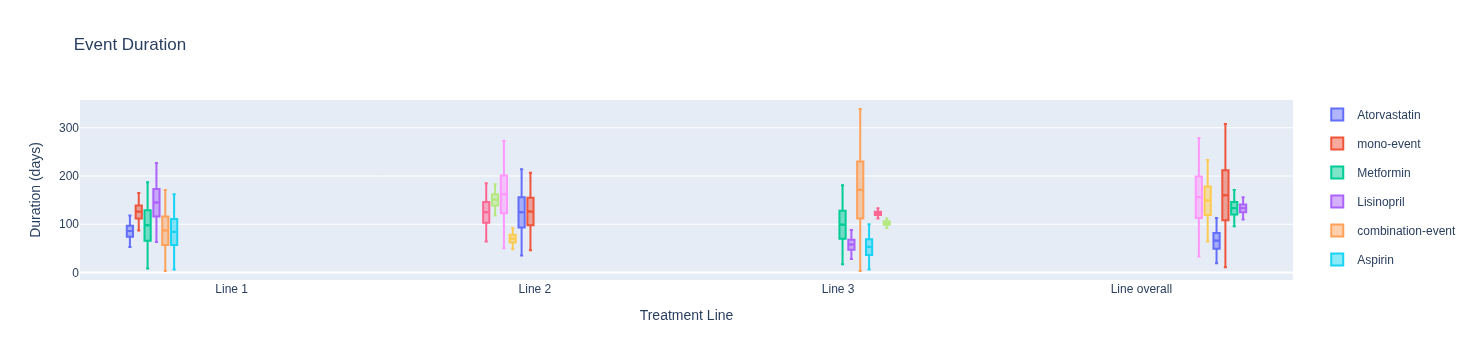

In [27]:
# Duration plot from mock data
plot_event_duration(mock_dur)

## 11. Advanced Options

Fine-tuning pathway computation with `era_collapse_size` and `combination_window`.

### Era collapse size

`era_collapse_size` merges consecutive eras of the same event that are separated by fewer than N days.
A larger value collapses more fragmented records into single continuous eras.

In [28]:
# Default era_collapse_size is 30 days; try a tighter gap
pw_gap10 = compute_pathways(
    cohort,
    cdm,
    cohort_specs,
    era_collapse_size=10,
)
summary_gap10 = summarise_treatment_pathways(pw_gap10, min_cell_count=0)
print("era_collapse_size=10:")
print(summary_gap10)

era_collapse_size=10:
SummarisedResult(6 rows, 1 result_id(s))


In [29]:
# Wider gap: 90 days
pw_gap90 = compute_pathways(
    cohort,
    cdm,
    cohort_specs,
    era_collapse_size=90,
)
summary_gap90 = summarise_treatment_pathways(pw_gap90, min_cell_count=0)
print("era_collapse_size=90:")
print(summary_gap90)

era_collapse_size=90:
SummarisedResult(6 rows, 1 result_id(s))


### Combination window tuning

Increasing `combination_window` captures more overlapping treatments as combination therapies.
A window of 0 means no combinations are detected.

In [30]:
# No combination window
pw_no_combo = compute_pathways(
    cohort,
    cdm,
    cohort_specs,
    combination_window=0,
)
summary_no_combo = summarise_treatment_pathways(pw_no_combo, min_cell_count=0)
print("combination_window=0:")
print(summary_no_combo)

combination_window=0:
SummarisedResult(6 rows, 1 result_id(s))


In [31]:
# Wide combination window: 60 days
pw_combo60 = compute_pathways(
    cohort,
    cdm,
    cohort_specs,
    combination_window=60,
)
summary_combo60 = summarise_treatment_pathways(pw_combo60, min_cell_count=0)
print("combination_window=60:")
print(summary_combo60)

combination_window=60:
SummarisedResult(6 rows, 1 result_id(s))


Sankey with combination_window=0:


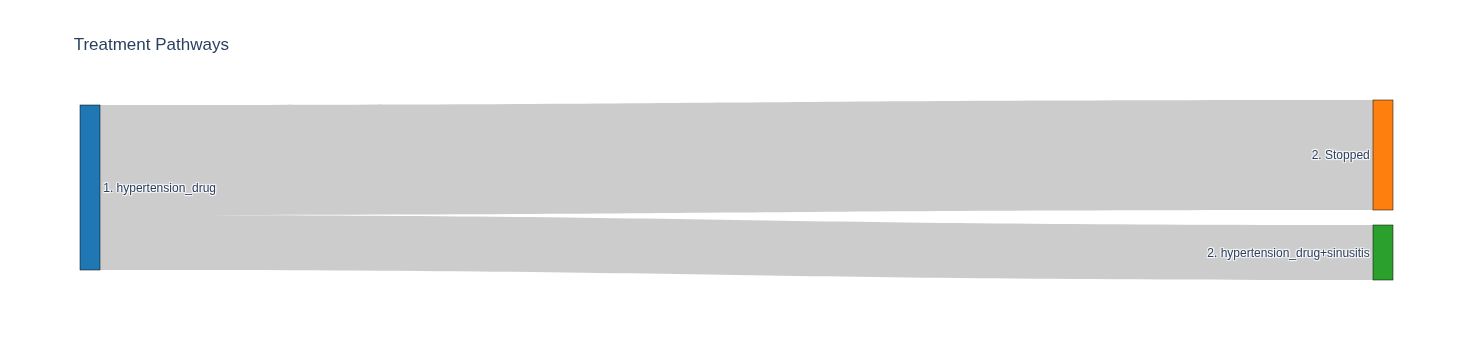

In [32]:
# Compare Sankey diagrams side by side
print("Sankey with combination_window=0:")
plot_sankey(summary_no_combo)

Sankey with combination_window=60:


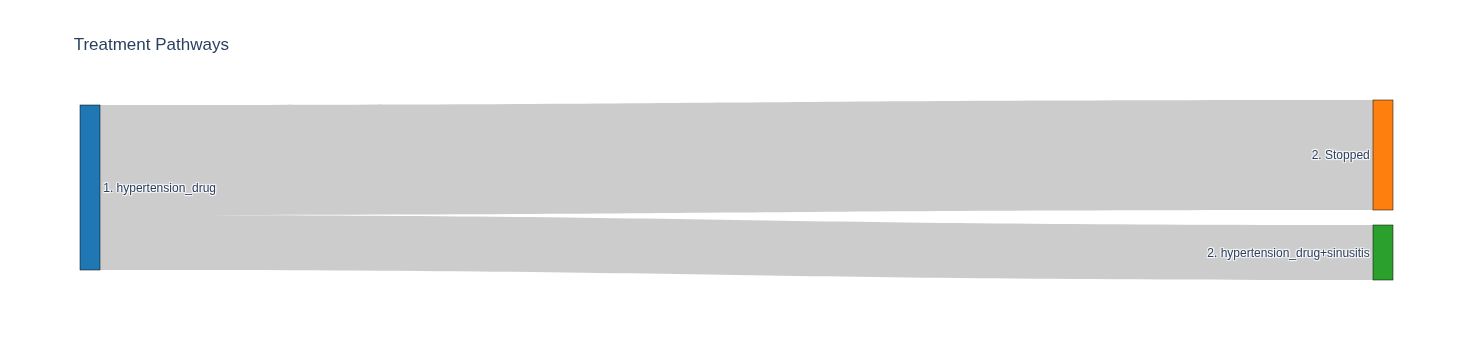

In [33]:
print("Sankey with combination_window=60:")
plot_sankey(summary_combo60)

### Combining multiple options

All parameters can be combined for a tailored analysis.

In [34]:
pw_advanced = compute_pathways(
    cohort,
    cdm,
    cohort_specs,
    combination_window=30,
    min_era_duration=7,
    max_path_length=4,
    era_collapse_size=60,
)
summary_advanced = summarise_treatment_pathways(pw_advanced, min_cell_count=0)
print("Advanced settings:")
print(summary_advanced)

Advanced settings:
SummarisedResult(6 rows, 1 result_id(s))


In [35]:
table_treatment_pathways(summary_advanced)

GT(_tbl_data=       variable_name                                 variable_level  \
0  treatment_pathway                              hypertension_drug   
1  treatment_pathway  hypertension_drug-hypertension_drug+sinusitis   
2     Number records                                                  
3    Number subjects                                                  
4  treatment_pathway                              hypertension_drug   
5  treatment_pathway  hypertension_drug-hypertension_drug+sinusitis   

  estimate_name [header_name]cdm_name\n[header_level]dbt-synthea  \
0             N                                                4   
1             N                                                2   
2             N                                                6   
3             N                                                6   
4             %                                            66.7%   
5             %                                            33.3%   

  target_cohort_name  
0       hypertension  
1       hypertension  
2       hypertension  
3       hypertension  
4       hypertension  
5       hypertension  , _body=<great_tables._gt_data.Body object at 0x727ce1b07890>, _boxhead=Boxhead([ColInfo(var='variable_name', type=<ColInfoTypeEnum.default: 1>, column_label='variable_name', column_align='left', column_width=None), ColInfo(var='variable_level', type=<ColInfoTypeEnum.default: 1>, column_label='variable_level', column_align='left', column_width=None), ColInfo(var='estimate_name', type=<ColInfoTypeEnum.default: 1>, column_label='estimate_name', column_align='left', column_width=None), ColInfo(var='[header_name]cdm_name\n[header_level]dbt-synthea', type=<ColInfoTypeEnum.default: 1>, column_label='dbt-synthea', column_align='right', column_width=None), ColInfo(var='target_cohort_name', type=<ColInfoTypeEnum.default: 1>, column_label='target_cohort_name', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x727ce1b53240>, _spanners=Spanners([SpannerInfo(spanner_id='cdm_name', spanner_level=0, spanner_label='cdm_name', spanner_units=None, spanner_pattern=None, vars=['[header_name]cdm_name\n[header_level]dbt-synthea'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x727ce1a663f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x727ce1a66120>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_level', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='estimate_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='[header_name]cdm_name\n[header_level]dbt-synthea', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='target_cohort_name', rownum=None, colnum=None, styles=[CellStyleFill(color='#4361ee')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_name', rownum=None, colnum=None, styles=[CellStyleText(color='#ffffff', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable_level', rownum=None, colnum=None, styles=[CellStyleText(color='#ffffff', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='estimate_name', 

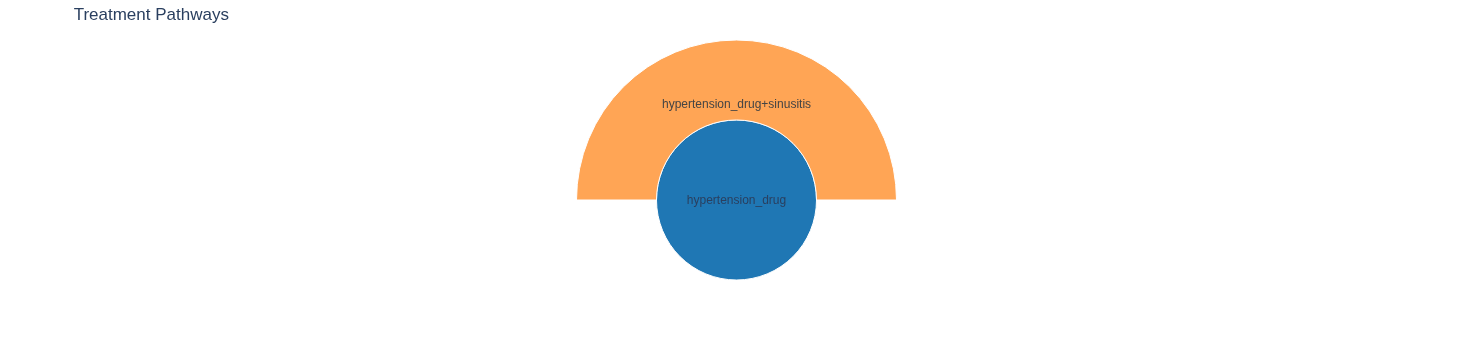

In [36]:
plot_sunburst(summary_advanced)

## 12. Summary

This notebook covered:

| Function | Purpose |
|---|---|
| `compute_pathways` | Compute per-person treatment sequences |
| `summarise_treatment_pathways` | Aggregate pathway frequencies |
| `summarise_event_duration` | Duration statistics per event |
| `table_treatment_pathways` | Formatted pathway frequency table |
| `table_event_duration` | Formatted duration table |
| `plot_sankey` | Sankey diagram of treatment flows |
| `plot_sunburst` | Sunburst chart of pathway hierarchy |
| `plot_event_duration` | Duration distribution plot |
| `mock_treatment_pathways` | Generate synthetic pathway results |

**Key parameters:** `combination_window`, `min_era_duration`, `max_path_length`, `era_collapse_size`, `min_cell_count`.

**Next steps:** Combine treatment pathway analysis with cohort survival (notebook 08) to study how treatment sequences relate to outcomes, or with drug utilisation (notebook 07) for deeper drug-level analysis.